# Case Studies for Statistical Methods 

In [29]:
# %pip install statsmodels

In [30]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.multivariate.manova as manova

# Chi-Square Test

Assume the expected distribution is 50% vegetarian and 50% non-vegetarian. You want to test if your sample data matches this distribution.

Goodness of fit.`

In [31]:
from scipy.stats import chisquare

# hypothetical observed frequencies
observed_frequencies = np.array([30,70]) # e.g., 30 Vegetarians and 70 Non-Vegetarians meals

# Expected frequencies (assuming 50-50 distribution)
total_meals = observed_frequencies.sum()
expected_frequencies = np.array([total_meals*0.5,total_meals*0.5])

# Perform Chi-square test
chi2_statistic, p_value = chisquare(observed_frequencies, f_exp=expected_frequencies)

# print results
print(f"Chi-square statistic: {chi2_statistic:.4f}")

# print using if-else statement
if p_value < 0.05:
    print(f"P_Value : {p_value:.4f} \n So Reject the null hypothesis (observed frequencies differ from expected frequencies)")
else:
    print(f"P_Value : {p_value:.4f} \n So Fail to reject the null hypothesis(observed frequencies are consistent with expected frequencies)")

Chi-square statistic: 16.0000
P_Value : 0.0001 
 So Reject the null hypothesis (observed frequencies differ from expected frequencies)


# Ch2 Contingency

In [32]:
from scipy.stats import chi2_contingency
# data load 
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [33]:
# create a contingency table of sex and smoker 
contingency_table = pd.crosstab(df['sex'], df['smoker'])
contingency_table

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [34]:
# Perform the chi2_contingency test
chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")#
print(f"Expected values: \n{expected}")

if p_value < 0.05:
    print("Reject the null hypothesis (Male and Female smokers are different in perspective of smoking)")
else:
    print("Fail to reject the null hypothesis (Male and Female smokers are the same in perspective of smoking)")
px.bar(contingency_table)

Chi-square statistic: 0.0000
P-value: 1.0000
Degrees of freedom: 1
Expected values: 
[[59.84016393 97.15983607]
 [33.15983607 53.84016393]]
Fail to reject the null hypothesis (Male and Female smokers are the same in perspective of smoking)


> create a contingency table of sex and day to check the null hypothesis that male and females are the same in perspective of days 

In [ ]:
# create a contingency table of sex and day  
contingency_table = pd.crosstab(df['sex'], df['day'])
contingency_table

day,Thur,Fri,Sat,Sun
sex,,,,
Male,30,10,59,58
Female,32,9,28,18


In [36]:
# Perform the chi2_contingency test
chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")#
print(f"Expected values: \n{expected}")

if p_value < 0.05:
    print("Reject the null hypothesis (Male and Female smokers are different in perspective of days)")
else:
    print("Fail to reject the null hypothesis (Male and Female smokers are the same in perspective of days)")
px.bar(contingency_table)

Chi-square statistic: 13.2220
P-value: 0.0042
Degrees of freedom: 3
Expected values: 
[[39.89344262 12.22540984 55.9795082  48.90163934]
 [22.10655738  6.77459016 31.0204918  27.09836066]]
Reject the null hypothesis (Male and Female smokers are different in perspective of days)


> create a contingency table of smoker and time to check the null hypothesis that smokers and non-smokers are the same in perspective of time 

In [37]:
contingency_table = pd.crosstab(df['smoker'], df['time']) 
contingency_table

time,Lunch,Dinner
smoker,,
Yes,23,70
No,45,106


In [39]:
# Perform the chi2_contingency test
chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Expected values: \n{expected}")

if p_value < 0.05:
    print("Reject the null hypothesis (Smoker and non smokers are different in perspective of time)")
else:
    print("Fail to reject the null hypothesis (Smoker and non smokers are the same in perspective of time)")
px.bar(contingency_table)

Chi-square statistic: 0.5054
P-value: 0.4771
Degrees of freedom: 1
Expected values: 
[[ 25.91803279  67.08196721]
 [ 42.08196721 108.91803279]]
Fail to reject the null hypothesis (Smoker and non smokers are the same in perspective of time)


---
# T-Tests 

## 1.One-Sample T-Test

<Axes: xlabel='age', ylabel='Count'>

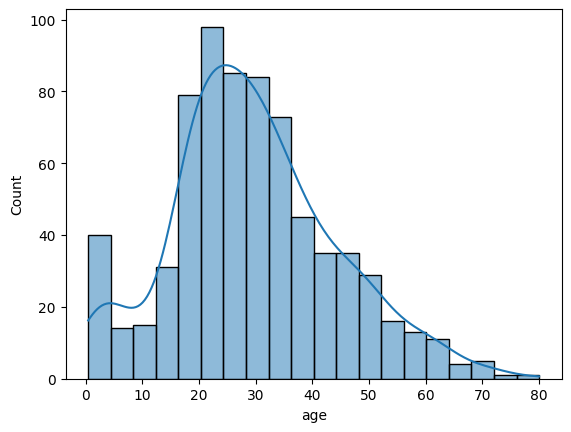

In [71]:
df = sns.load_dataset('titanic')
sns.histplot(df['age'],kde=True)

In [114]:
df['age']=df['age'].fillna(df['age'].median())
df['fare']=df['fare'].fillna(df['fare'].median())

In [76]:
# shapiro - wilk test to check the data normalization 
from scipy.stats import shapiro

# Perform Shapiro-Wilk test
stat, p_value = shapiro(df['age'])
print(f"Shapiro-Wilk test statistic: {stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject the null hypothesis (Data is not normally distributed)")
else:
    print("Fail to reject the null hypothesis (Data is normally distributed)")

Shapiro-Wilk test statistic: 0.9541046573646538
P-value: 4.651141686041376e-16
Reject the null hypothesis (Data is not normally distributed)


In [77]:
# find data normality using skewness and kurtosis of age 
from scipy import stats
skewness = stats.skew(df['age'])
kurtosis = stats.kurtosis(df['age'])

# print using if-else statement
if skewness < 0:
    print("Data is negatively skewed")
else:
    print("Data is positively skewed")
print(f"Skewness: {skewness}")

if kurtosis > 3:
    print("Data is leptokurtic")
else:
    print("Data is platykurtic ")

print(f"Kurtosis: {kurtosis}")


Data is positively skewed
Skewness: 0.5093852558219663
Data is platykurtic 
Kurtosis: 0.9815760369363544


mu = 35

is there any difference between ages of people and mu?

In [85]:
# Apply One Sample T Test on Age Column 
from scipy import stats
stats, p_value =stats.ttest_1samp(df['age'], 30)
# print the results 
print(f"Test statistic: {stats}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject the null hypothesis (Age is different from 30)")
else:
    print("Fail to reject the null hypothesis (Age is the same as 30)")

Test statistic: -1.4636686761878148
P-value: 0.1436375821196688
Fail to reject the null hypothesis (Age is the same as 30)


## 2.Two Sample T Test

In [95]:
# Apply Two Sample T Test on ages of male and female passengers 
from scipy import stats
age_male = df[df['sex'] == 'male']['age']
age_female = df[df['sex'] == 'female']['age']
stats, p_value =stats.ttest_ind(age_male, age_female)
# print the results 
print(f"Test statistic: {stats}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject the null hypothesis (Age of  Male and Female in the titanic passengers is different)")
else:
    print("Fail to reject the null hypothesis (Age of  Male and Female in the titanic passengers is the same)")

Test statistic: 2.4279606481426024
P-value: 0.015381536989875317
Reject the null hypothesis (Age of  Male and Female in the titanic passengers is different)


# 3.ANOVA 

In [96]:
df =sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [104]:
df[['age','pclass']].head()

,age,pclass
0,22.0,3
1,38.0,1
2,26.0,3
3,35.0,1
4,35.0,3


## One-way ANOVA
1. There is a difference between ages of First, second and third class passengers?
   
H0: There is no difference.

H1: There is a significant Difference.

In [106]:
# Apply statsmodel to build a linear regression model
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('age ~ pclass',data=df).fit()
anova_table = sm.stats.anova_lm(model)
print(anova_table)

# print the results using if-else statement
if anova_table['PR(>F)'][0] < 0.05:
    print("Reject the null hypothesis (there is difference in ages of passengers in different class)")
else:
    print("Fail to reject the null hypothesis (there is no difference in ages of passengers in different class)")

             df         sum_sq       mean_sq           F        PR(>F)
pclass      1.0   20511.429755  20511.429755  112.386893  1.756699e-24
Residual  712.0  129945.206190    182.507312         NaN           NaN
Reject the null hypothesis (there is difference in ages of passengers in different class)


# Post Hoc Test 

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
     1      2      nan   nan   nan   nan  False
     1      3      nan   nan   nan   nan  False
     2      3      nan   nan   nan   nan  False
-----------------------------------------------


<Axes: xlabel='pclass', ylabel='age'>

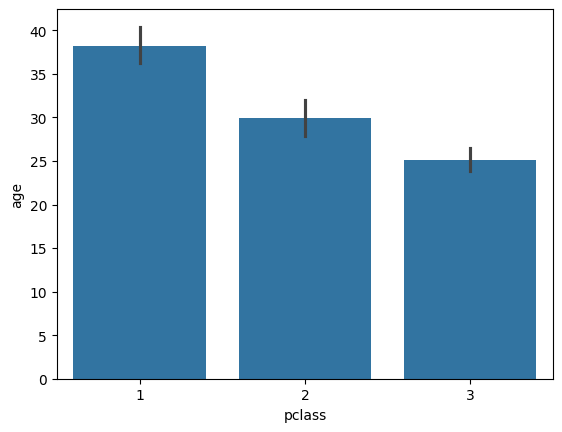

In [111]:
# Tukey HSD pair-wise comparison 
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey_results = pairwise_tukeyhsd(endog=df['age'],groups=df['pclass'], alpha=0.05)
print(tukey_results.summary())
sns.barplot(df,x='pclass',y='age')

<Axes: xlabel='age', ylabel='Count'>

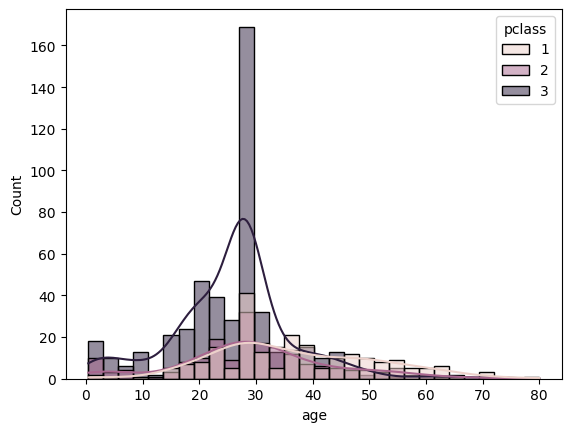

In [115]:
sns.histplot(df,x='age',hue='pclass',kde=True)

# Two way  ANOVA

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
# model = ols('age ~ pclass + who + pclass:who',data=df).fit()
model = ols('age ~ pclass*who ',data = df ).fit()
anova_table = sm.stats.anova_lm(model)
print(anova_table)

               df        sum_sq       mean_sq           F        PR(>F)
who           2.0  48488.113382  24244.056691  240.644225  3.506602e-84
pclass        1.0  11863.085431  11863.085431  117.751870  7.658356e-26
pclass:who    2.0   1354.296985    677.148492    6.721312  1.267414e-03
Residual    885.0  89160.627671    100.746472         NaN           NaN


In [123]:
# Apply Tukey HSD for two way ANOVA 
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey_results = pairwise_tukeyhsd(df['age'],df['pclass'] * df['who'], alpha=0.05)
print(tukey_results.summary())

          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------------
          child      childchild  -3.2763 0.9988 -17.8994 11.3468  False
          child childchildchild  -1.0024    1.0 -14.3937 12.3889  False
          child             man  32.0245    0.0   18.959 45.0901   True
          child          manman  25.2608    0.0  12.1321 38.3895   True
          child       manmanman  20.8822    0.0   8.0148 33.7496   True
          child           woman  26.9382    0.0  13.7766 40.0999   True
          child      womanwoman   24.233    0.0  10.9181  37.548   True
          child womanwomanwoman  20.0879 0.0001   7.0086 33.1672   True
     childchild childchildchild   2.2739  0.995  -5.9803 10.5281  False
     childchild             man  35.3009    0.0  27.5863 43.0154   True
     childchild          manman  28.5371    0.0   20.716 36.3582

In [124]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
# model = ols('age ~ sex + who + pclass:who',data=df).fit()
model = ols('age ~ sex*who ',data = df ).fit()
anova_table = sm.stats.anova_lm(model)
print(anova_table)

             df         sum_sq       mean_sq           F        PR(>F)
sex         1.0     993.809034    993.809034    8.615627  3.418926e-03
who         2.0   47557.229173  23778.614586  206.143904  2.990864e-74
sex:who     2.0      87.996198     43.998099    0.381433  6.829943e-01
Residual  887.0  102315.085263    115.349589         NaN           NaN


In [126]:
# Apply Tukey HSD for two way ANOVA 
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey_results = pairwise_tukeyhsd(df['age'],df['sex'] + df['who'], alpha=0.05)
print(tukey_results.summary())

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1      group2   meandiff p-adj   lower    upper   reject
----------------------------------------------------------------
femalechild femalewoman  24.0084    0.0  19.4706  28.5462   True
femalechild   malechild  -1.7426 0.8815  -7.8152   4.3301  False
femalechild     maleman  24.7693    0.0  20.3881  29.1505   True
femalewoman   malechild  -25.751    0.0 -30.4333 -21.0686   True
femalewoman     maleman   0.7609 0.7773   -1.299   2.8207  False
  malechild     maleman  26.5118    0.0  21.9811  31.0426   True
----------------------------------------------------------------


<Axes: xlabel='who', ylabel='age'>

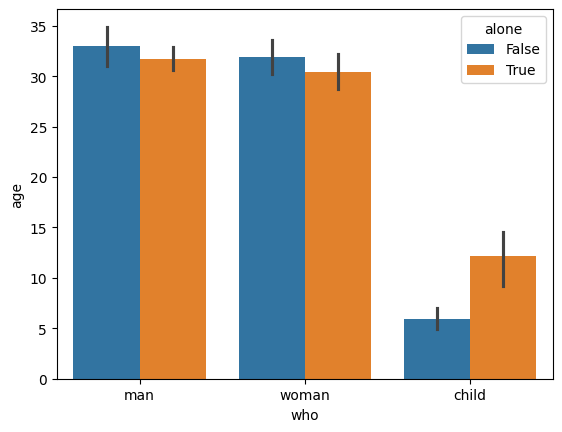

In [127]:
sns.barplot(df,x='who',y='age',hue='alone')

---
# Correlation 

In [128]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: >

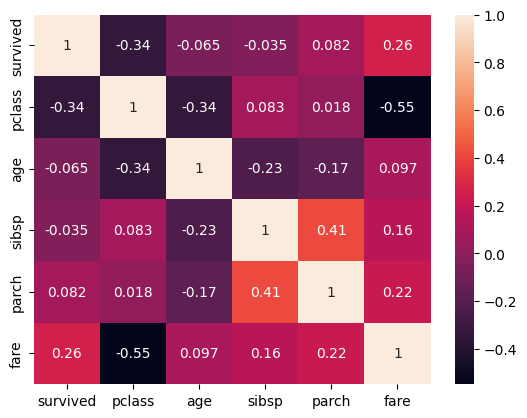

In [132]:
# create a heatmap of numerical columns 

sns.heatmap(df.select_dtypes(include=['number']).corr(),annot=True)

<Axes: >

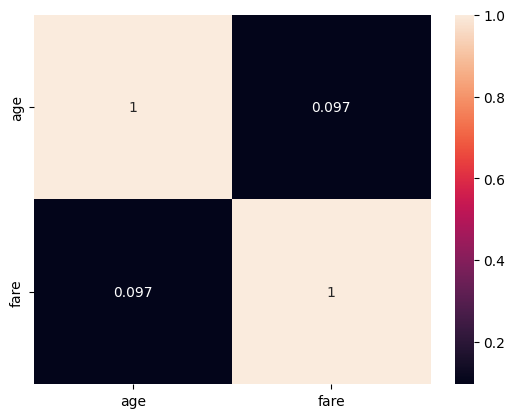

In [133]:
sns.heatmap(df[['age','fare']].corr(),annot=True)

In [134]:
age_male = df[df['sex'] == 'male']['age']
age_female = df[df['sex']=='female']['age']

In [135]:
age_male.corr(age_female)

nan

In [136]:
# Let's see correlation on tips dataset 
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='tip'>

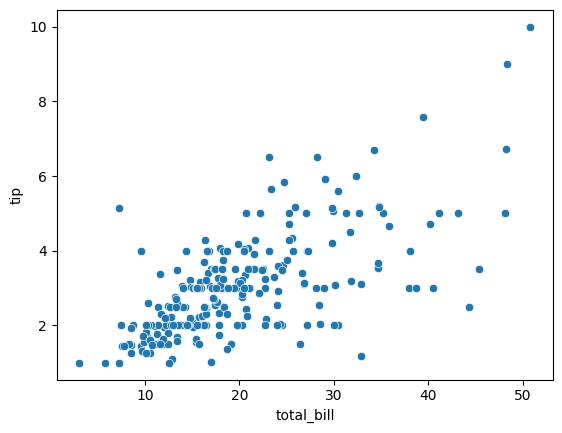

In [144]:
# Question :Is tip increases with total bill ?
sns.scatterplot(tips,x='total_bill',y='tip')

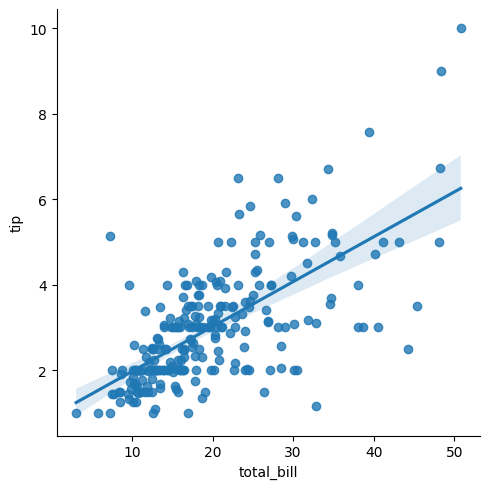

In [145]:
sns.lmplot(x='total_bill',y='tip',data=tips)

<Axes: >

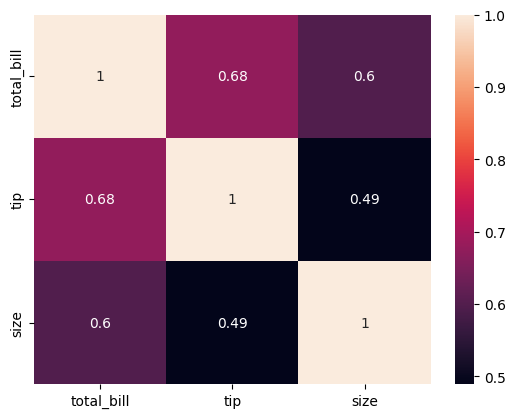

In [138]:
sns.heatmap(tips.select_dtypes(include=['number']).corr(),annot=True)

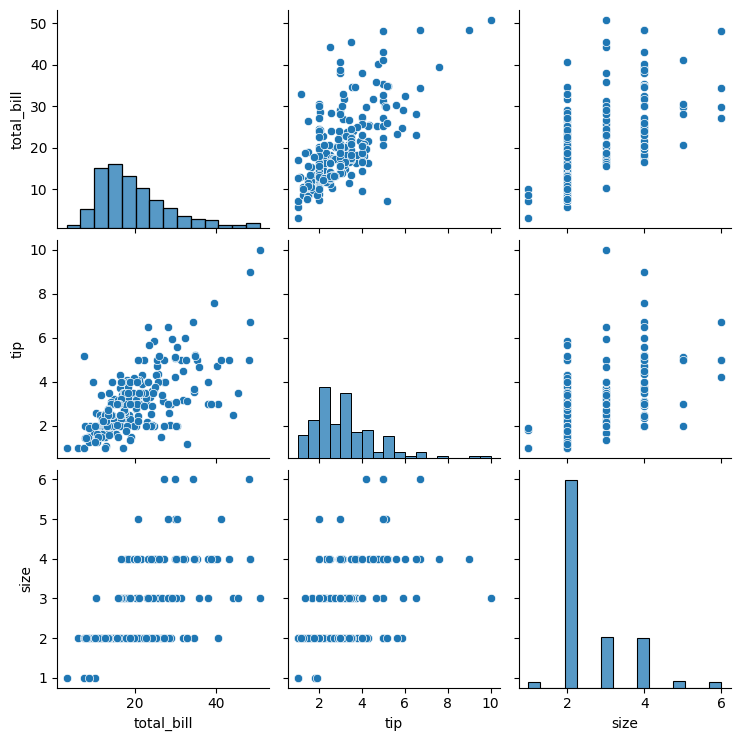

In [ ]:
sns.pairplot(tips) # pair plot mostly for numerical columns 

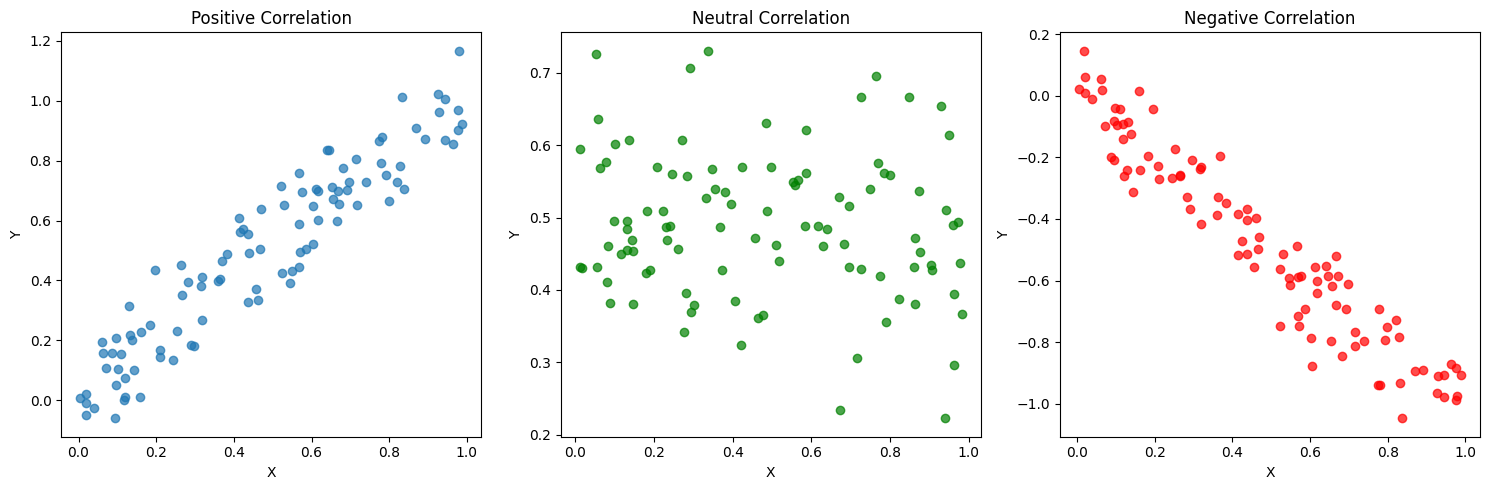

In [147]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(0)

# Generate synthetic data
# Positive correlation
x = np.random.rand(100)
y_pos = x + np.random.normal(0, 0.1, 100)

# Neutral correlation
x_neutral = np.random.rand(100)
y_neutral = np.random.normal(0.5, 0.1, 100)

# Negative correlation
y_neg = -x + np.random.normal(0, 0.1, 100)

# Plotting the correlations
plt.figure(figsize=(15, 5))

# Positive Correlation
plt.subplot(1, 3, 1)
plt.scatter(x, y_pos, alpha=0.7)
plt.title('Positive Correlation')
plt.xlabel('X')
plt.ylabel('Y')

# Neutral Correlation
plt.subplot(1, 3, 2)
plt.scatter(x_neutral, y_neutral, alpha=0.7, color='green')
plt.title('Neutral Correlation')
plt.xlabel('X')
plt.ylabel('Y')

# Negative Correlation
plt.subplot(1, 3, 3)
plt.scatter(x, y_neg, alpha=0.7, color='red')
plt.title('Negative Correlation')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()